# Supervised Learning: Predictive Maintenance with a Decision Tree

In this notebook we use the same **AI4I 2020 Predictive Maintenance Dataset** as in the anomaly-detection example.

This time the task is supervised learning:

> Can we learn from labeled data whether a machine state leads to a failure?

Dataset: **AI4I 2020 Predictive Maintenance Dataset** from UCI  
Source: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset


## Learning Objectives

After this notebook, you should be able to explain:

- why accuracy can be misleading when failures are rare,
- how a supervised train/test split works for labeled data,
- how a decision tree is trained for binary classification,
- how to read a confusion matrix,
- how to interpret precision, recall, and F1 in a practical setting.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the Dataset

The dataset contains 10,000 machine states. The target variable `Machine failure` indicates whether a machine failure occurred.

Unlike anomaly detection, we use these labels directly to train a supervised model.


In [8]:
url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"

df = pd.read_csv(url, compression="zip", encoding="utf-8-sig")
print(df.shape)
df.head()


(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Why Accuracy Is Problematic

First, we inspect the class distribution. Predictive-maintenance data is typically highly imbalanced: there are many normal machine states and only a few failures.


In [5]:
class_counts = df["Machine failure"].value_counts().rename(index={0: "normal", 1: "failure"})
class_counts


Machine failure
normal     9661
failure     339
Name: count, dtype: int64

In [9]:
failure_rate = df["Machine failure"].mean()
normal_rate = 1 - failure_rate

print(f"Failure rate: {failure_rate:.2%}")
print(f"Accuracy if we always predict normal: {normal_rate:.2%}")


Failure rate: 3.39%
Accuracy if we always predict normal: 96.61%


A model that **always predicts `normal`** would have a very high accuracy here. Nevertheless, it would be useless for predictive maintenance because it would not detect a single failure.

Therefore, we need additional metrics:

- **Precision:** When the model raises an alarm, how often is it correct?
- **Recall:** How many real failures does the model find?
- **F1:** A compromise between precision and recall.


## 3. Features and Target Variable

We first use only the technical sensor features.

The columns `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` are already failure indicators and are intentionally not used as input features. Otherwise, the task would become artificially easy.


In [10]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
target = "Machine failure"

X = df[features]
y = df[target]

X.describe().T


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


## 4. Train/Test Split

Because this is supervised learning, both normal and faulty examples may appear in the training set.

The important argument here is `stratify=y`: it keeps the failure rate approximately equal in the training and test sets.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
print("Training data: ",X_train.shape)
print("Test data: ",X_test.shape)

Training data:  (7500, 5)
Test data:  (2500, 5)


## 5. Train a Decision Tree

A decision tree learns decision rules of the form:

```text
if Torque <= ... and Rotational speed > ... then ...
```

We limit the depth of the tree so that the model remains interpretable. In addition, we use `class_weight="balanced"` because failures are rare. This gives failure examples more weight during training.


In [12]:
tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)


## 6. Confusion Matrix

The confusion matrix shows which cases were predicted correctly and incorrectly.

For `failure = 1`:

- **True Positive:** a failure was correctly detected.
- **False Positive:** a normal state was incorrectly flagged as a failure.
- **False Negative:** a failure was missed.
- **True Negative:** a normal state was correctly classified as normal.


True positives  (failure correctly detected): 77
False positives (normal machine flagged):     189
False negatives (failure missed):            8
True negatives  (normal correctly ignored):  2226


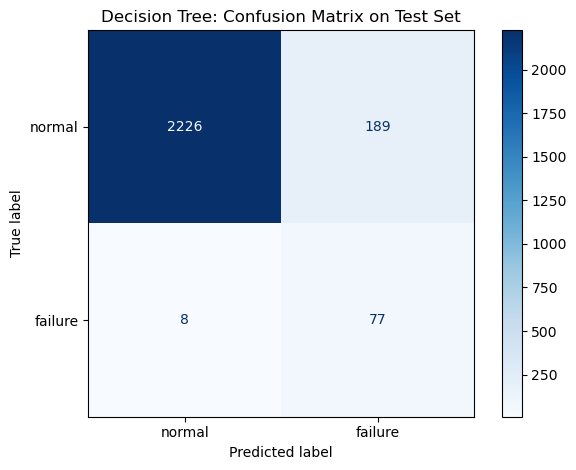

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "failure"])
disp.plot(cmap="Blues")
plt.title("Decision Tree: Confusion Matrix on Test Set")
plt.tight_layout()

tn, fp, fn, tp = cm.ravel()
print(f"True positives  (failure correctly detected): {tp}")
print(f"False positives (normal machine flagged):     {fp}")
print(f"False negatives (failure missed):            {fn}")
print(f"True negatives  (normal correctly ignored):  {tn}")


## 8. Precision, Recall, and F1

Now we compute the metrics for the important class `failure = 1`.

- **Precision:** the fraction of correct alarms among all alarms.
- **Recall:** the fraction of detected failures among all real failures.
- **F1:** the harmonic mean of precision and recall.


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")


Accuracy:  0.921
Precision: 0.289
Recall:    0.906
F1:        0.439


## 9. Interpretation

Accuracy is relatively high for this dataset because normal machine states dominate. For predictive maintenance, accuracy alone is therefore not sufficient.

The more important question is:

```text
How many real failures do we detect, and how many false alarms do we create?
```

Precision, recall, F1, and the confusion matrix answer this question much better than accuracy alone.

A decision tree is also useful for teaching because its rules make visible which sensor ranges are associated with failures.
